# SST 订正推理演示
在 notebook 中加载 results 保存的模型，并可视化某一天的订正结果。

## 1. 加载依赖与配置路径

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset as NCDataset

from inference import correct_run_from_nc, visualize_run_step, compute_run_rmse

# 路径配置
BASE_DIR = "/home/user3/scratch/SST Correction/CResUNet"
MODEL_PATH = os.path.join(BASE_DIR, "results", "best_model.pth")
FORECAST_PATH = os.path.join(BASE_DIR, "data", "forecast_structured.nc")
REANALYSIS_PATH = os.path.join(BASE_DIR, "data", "reanalysis_structured.nc")


## 2. 读取 results 中已保存的模型

In [2]:
print("Model path:", MODEL_PATH)
print("Forecast path:", FORECAST_PATH)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("未找到模型文件，请确认 results/best_model.pth 是否存在。")
if not os.path.exists(FORECAST_PATH):
    raise FileNotFoundError("未找到数据文件，请确认 data/forecast_structured.nc 是否存在。")

Model path: /home/user3/scratch/SST Correction/CResUNet/results/best_model.pth
Forecast path: /home/user3/scratch/SST Correction/CResUNet/data/forecast_structured.nc


## 3. 加载待订正数据与特征工程复现

In [3]:
with NCDataset(FORECAST_PATH, "r") as ds:
    sst = ds.variables["sst"]
    land_mask = ds.variables["land_mask"][:]
    print("Forecast sst shape:", sst.shape)
    print("Land mask shape:", land_mask.shape)

Forecast sst shape: (360, 120, 608, 704)
Land mask shape: (608, 704)


## 4. 选择某一天并生成订正结果

In [4]:
# 选择某天的 run 索引
run_idx = 0

corrected_sst, pred_bias = correct_run_from_nc(
    model_path=MODEL_PATH,
    forecast_path=FORECAST_PATH,
    run_idx=run_idx,
    device="cpu"
 )

print("corrected_sst shape:", corrected_sst.shape)
print("pred_bias shape:", pred_bias.shape)

corrected_sst shape: (120, 608, 704)
pred_bias shape: (120, 608, 704)


## 5. 可视化订正前后对比（折线/散点）

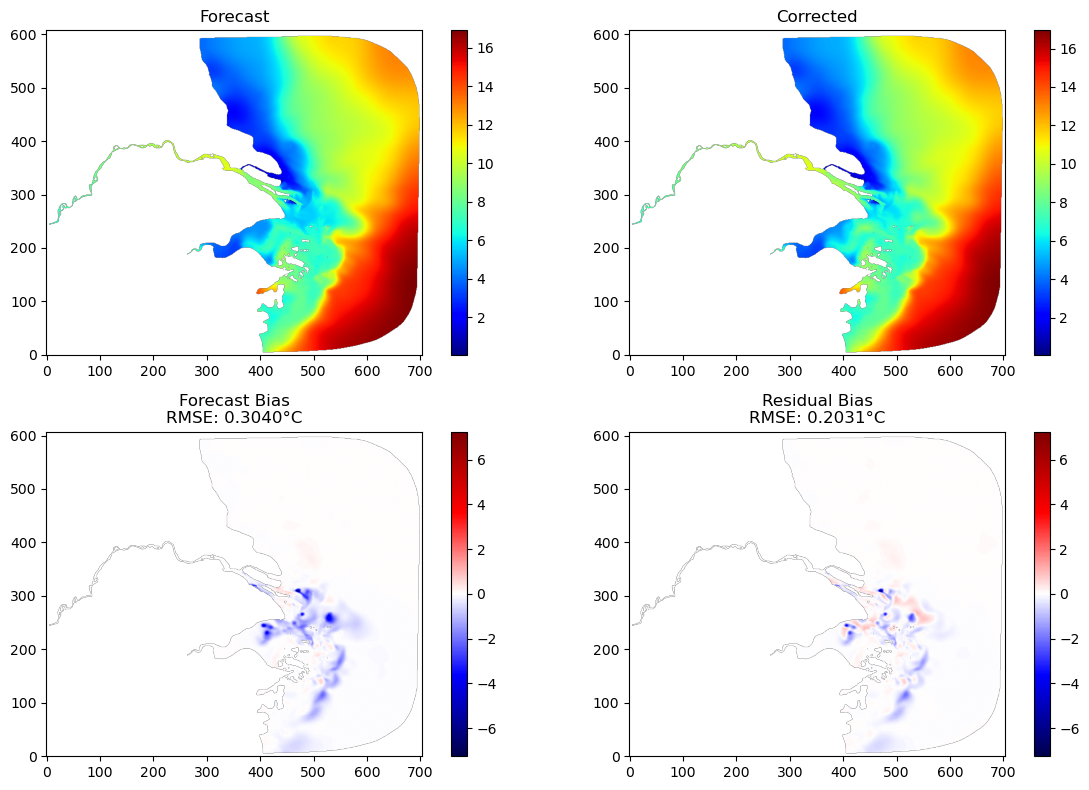

In [5]:
# 选一个时间步进行可视化
t = 119

visualize_run_step(
    forecast_path=FORECAST_PATH,
    reanalysis_path=REANALYSIS_PATH,
    run_idx=run_idx,
    t=t,
    corrected_sst=corrected_sst,
    pred_bias=pred_bias,
    mask_land=True,
 )

In [6]:
# 统计该天 120 小时 RMSE（Forecast vs Corrected）
rmse_forecast, rmse_corrected = compute_run_rmse(
    forecast_path=FORECAST_PATH,
    reanalysis_path=REANALYSIS_PATH,
    run_idx=run_idx,
    corrected_sst=corrected_sst,
 )

RMSE (Forecast): 0.18487°C
RMSE (Corrected): 0.14981°C
